# Analisis Discriminante Lineal (LDA) - PYTHON
## Dataset: Anemia infantil - ENDES 2024 (RECH6)
**Universidad Nacional del Altiplano**

Metodologia basada en: *Analisis discriminante lineal (LDA)* - Dr. Edgar Eloy Carpio Vargas, FINESI-2024

**Variable dependiente (Y):** grupo_anemia (Con_anemia / Sin_anemia) - Directriz OMS 2024 / RM 251-2024-MINSA

**Variables independientes (X):**
- edad_meses: Edad del nino en meses
- peso_kg: Peso en kilogramos
- talla_cm: Talla en centimetros
- talla_edad_z: Z-score Talla/Edad (OMS)
- peso_edad_z: Z-score Peso/Edad (OMS)

> **Este notebook contiene UNICAMENTE el analisis LDA** (lineal). El analisis QDA (cuadratico) esta en un notebook separado.


In [1]:
from google.colab import files
uploaded = files.upload()  # selecciona RECH6_2024.csv (archivo original, sin modificar)

Saving RECH6_2024.csv to RECH6_2024.csv


In [2]:
!pip install scikit-learn scipy pandas matplotlib seaborn -q

## 0. Importaciones y configuracion inicial

Cargamos las librerias necesarias para todo el analisis (pandas, numpy, scipy, sklearn, matplotlib, seaborn).

In [3]:
# =====================================================================
# ANALISIS DISCRIMINANTE LINEAL (LDA)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                              roc_curve, auc, ConfusionMatrixDisplay)

pd.set_option('display.width', 120)
np.random.seed(123)

## Paso 0.1: Preparacion del dataset desde el archivo crudo

El archivo de ENDES usa codigos numericos para 'valor no medido' (documentados en el diccionario INEI). Se excluyen esos codigos (no se alteran datos reales) y se convierten las unidades a su valor real.

In [4]:
# =====================================================================
# PASO 0.1: PREPARACION DEL DATASET (a partir del archivo crudo RECH6_2024.csv)
# =====================================================================

print("=" * 70)
print("PASO 0.1: PREPARACION DEL DATASET DESDE EL ARCHIVO CRUDO")
print("=" * 70)

df_crudo = pd.read_csv("RECH6_2024.csv", sep=";", low_memory=False)
print(f"\nDataset original (crudo): {df_crudo.shape}")

datos = df_crudo[['HC1', 'HC2', 'HC3', 'HC57A', 'HC70', 'HC71']].copy()
datos.columns = ['edad_meses', 'peso_kg_x10', 'talla_cm_x10', 'anemia_oms',
                  'talla_edad_z_x100', 'peso_edad_z_x100']

mask_validos = (
    (datos['peso_kg_x10'] < 999) &
    (datos['talla_cm_x10'] < 9999) &
    (datos['anemia_oms'].isin([1, 2, 3, 4])) &
    (datos['talla_edad_z_x100'].abs() < 9000) &
    (datos['peso_edad_z_x100'].abs() < 9000)
)
print(f"\nFilas excluidas por codigo de 'no medido': {(~mask_validos).sum()}")
print(f"Filas validas: {mask_validos.sum()} de {len(datos)}")

datos = datos[mask_validos].copy()
datos['peso_kg'] = datos['peso_kg_x10'] / 10
datos['talla_cm'] = datos['talla_cm_x10'] / 10
datos['talla_edad_z'] = datos['talla_edad_z_x100'] / 100
datos['peso_edad_z'] = datos['peso_edad_z_x100'] / 100
datos['grupo_anemia'] = np.where(datos['anemia_oms'] == 4, 'Sin_anemia', 'Con_anemia')

datos = datos[['edad_meses', 'peso_kg', 'talla_cm', 'talla_edad_z', 'peso_edad_z',
               'anemia_oms', 'grupo_anemia']].copy()

X_cols = ['edad_meses', 'peso_kg', 'talla_cm', 'talla_edad_z', 'peso_edad_z']
Y_col = 'grupo_anemia'

print(f"\nDataset final, listo para el analisis discriminante:")
print(datos.shape)
print("\nDistribucion de la variable dependiente:")
print(datos[Y_col].value_counts())
print(datos[Y_col].value_counts(normalize=True).round(3) * 100, "%")

PASO 0.1: PREPARACION DEL DATASET DESDE EL ARCHIVO CRUDO

Dataset original (crudo): (20290, 43)

Filas excluidas por codigo de 'no medido': 1984
Filas validas: 18306 de 20290

Dataset final, listo para el analisis discriminante:
(18306, 7)

Distribucion de la variable dependiente:
grupo_anemia
Sin_anemia    12552
Con_anemia     5754
Name: count, dtype: int64
grupo_anemia
Sin_anemia    68.6
Con_anemia    31.4
Name: proportion, dtype: float64 %


## Paso 1: Revision de los datos

Revisamos la estructura, dimensiones y distribucion de grupos del dataset ya preparado.

In [5]:
# =====================================================================
# PASO 1: CARGAR Y PREPARAR LOS DATOS
# =====================================================================
print("\n" + "=" * 70)
print("PASO 1: REVISION DE LOS DATOS")
print("=" * 70)

print(f"\nPrimeras filas:")
print(datos[X_cols + [Y_col]].head())

print(f"\nEstadisticos descriptivos de los predictores:")
print(datos[X_cols].describe().round(2))

print(f"\nValores nulos por columna:")
print(datos[X_cols + [Y_col]].isnull().sum())


PASO 1: REVISION DE LOS DATOS

Primeras filas:
   edad_meses  peso_kg  talla_cm  talla_edad_z  peso_edad_z grupo_anemia
0          43     15.0      96.2         -0.88        -0.10   Sin_anemia
1          13      9.1      71.4         -1.67        -0.17   Sin_anemia
2          19     11.9      80.2         -0.78         0.91   Sin_anemia
3          13     10.0      74.7         -0.27         0.67   Con_anemia
4          18     11.2      79.5         -1.19         0.13   Sin_anemia

Estadisticos descriptivos de los predictores:
       edad_meses   peso_kg  talla_cm  talla_edad_z  peso_edad_z
count    18306.00  18306.00  18306.00      18306.00     18306.00
mean        32.53     13.27     88.89         -0.88        -0.14
std         15.60      3.46     11.82          1.01         1.04
min          6.00      4.90     55.20         -5.51        -4.54
25%         19.00     10.60     79.60         -1.55        -0.83
50%         33.00     13.10     89.90         -0.88        -0.18
75%         

## Exploracion grafica de los predictores

Histogramas y dispersion por pares para ver como se distribuyen los predictores en cada grupo (Con_anemia / Sin_anemia).


EXPLORACION GRAFICA


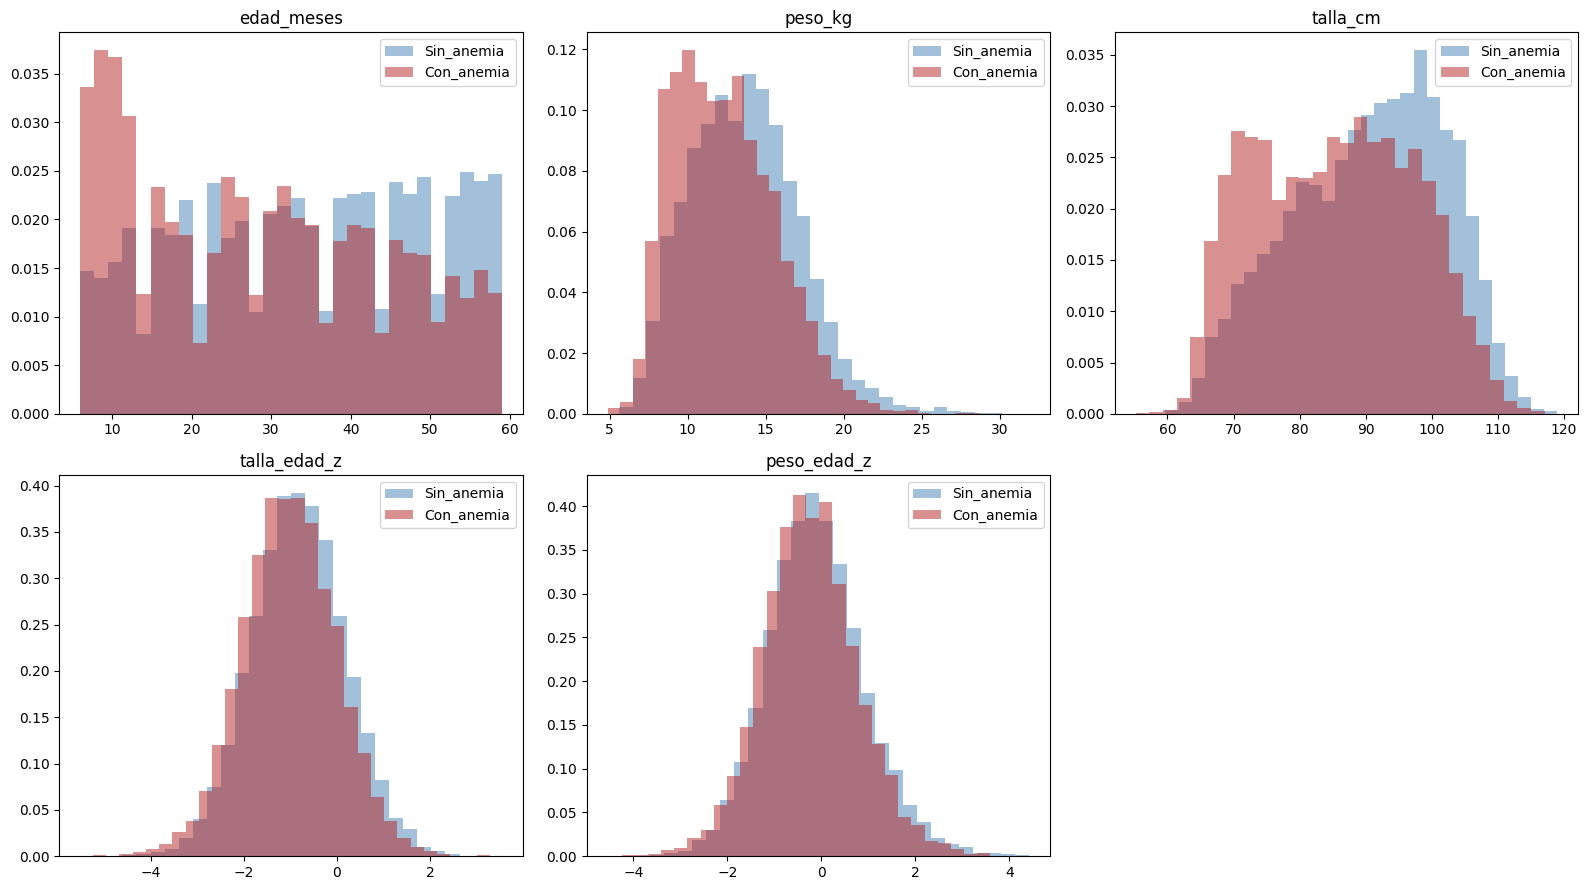

Grafico guardado: 1_histogramas_predictores.png


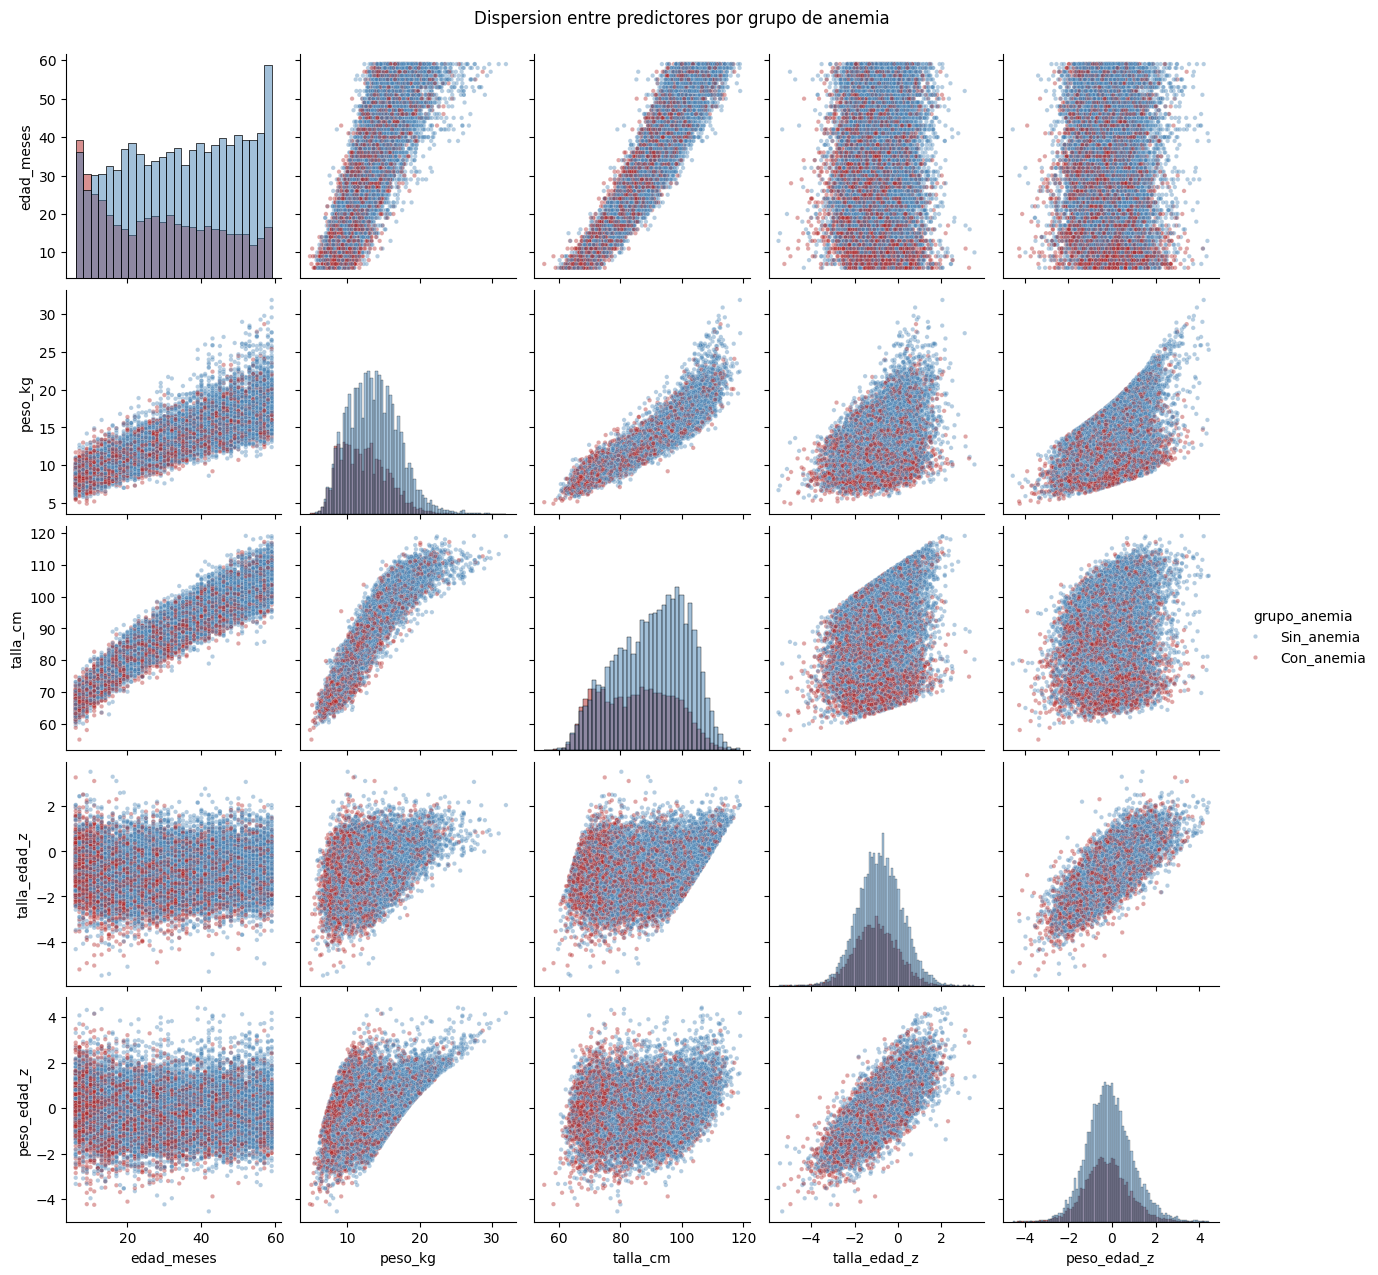

Grafico guardado: 2_pairplot.png


In [6]:
# =====================================================================
# EXPLORACION GRAFICA
# =====================================================================
print("\n" + "=" * 70)
print("EXPLORACION GRAFICA")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(X_cols):
    for grupo, color in zip(['Sin_anemia', 'Con_anemia'], ['steelblue', 'firebrick']):
        subset = datos[datos[Y_col] == grupo][col]
        axes[i].hist(subset, alpha=0.5, label=grupo, color=color, bins=30, density=True)
    axes[i].set_title(col)
    axes[i].legend()
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('1_histogramas_predictores.png', dpi=120)
plt.show()
print("Grafico guardado: 1_histogramas_predictores.png")

g = sns.pairplot(datos[X_cols + [Y_col]], hue=Y_col,
                  palette={'Sin_anemia': 'steelblue', 'Con_anemia': 'firebrick'},
                  diag_kind='hist', plot_kws={'alpha': 0.4, 's': 10})
g.fig.suptitle("Dispersion entre predictores por grupo de anemia", y=1.02)
plt.savefig('2_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("Grafico guardado: 2_pairplot.png")

## Probabilidades previas (prior probabilities)

Probabilidad previa de pertenecer a cada grupo, segun el tamano relativo de cada uno (igual que en el ejemplo de insectos del PDF).

In [7]:
# =====================================================================
# PROBABILIDADES PREVIAS (PRIOR PROBABILITIES)
# =====================================================================
print("\n" + "=" * 70)
print("PROBABILIDADES PREVIAS (segun tamano de cada grupo)")
print("=" * 70)
prior = datos[Y_col].value_counts(normalize=True).sort_index()
print(prior.round(4))


PROBABILIDADES PREVIAS (segun tamano de cada grupo)
grupo_anemia
Con_anemia    0.3143
Sin_anemia    0.6857
Name: proportion, dtype: float64


## Paso 2: Dividir los datos (train / test)

Dividimos el dataset en 70% entrenamiento y 30% prueba, manteniendo la proporcion de clases (estratificado).

In [8]:
# =====================================================================
# PASO 2: DIVIDIR LOS DATOS (TRAIN / TEST)
# =====================================================================
print("\n" + "=" * 70)
print("PASO 2: DIVISION TRAIN / TEST (70% / 30%)")
print("=" * 70)

X = datos[X_cols].values
y = datos[Y_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=123, stratify=y
)
print(f"Train: {X_train.shape[0]} observaciones")
print(f"Test : {X_test.shape[0]} observaciones")


PASO 2: DIVISION TRAIN / TEST (70% / 30%)
Train: 12814 observaciones
Test : 5492 observaciones


## Supuesto 1: Normalidad univariante (Test de Shapiro-Wilk)

Contrastamos si cada variable se distribuye normalmente dentro de cada grupo. Ho: la variable es normal dentro del grupo.


SUPUESTO: NORMALIDAD UNIVARIANTE (Test de Shapiro-Wilk)
Ho: la variable se distribuye normalmente dentro del grupo

     grupo     variable  estadistico_W  p_value
Sin_anemia   edad_meses         0.9545  0.00000
Sin_anemia      peso_kg         0.9894  0.00112
Sin_anemia     talla_cm         0.9753  0.00000
Sin_anemia talla_edad_z         0.9959  0.21983
Sin_anemia  peso_edad_z         0.9869  0.00018
Con_anemia   edad_meses         0.9308  0.00000
Con_anemia      peso_kg         0.9651  0.00000
Con_anemia     talla_cm         0.9669  0.00000
Con_anemia talla_edad_z         0.9948  0.08950
Con_anemia  peso_edad_z         0.9815  0.00001

Nota: con N grande, Shapiro-Wilk tiende a rechazar Ho por desviaciones
minimas de la normalidad. Se complementa con histogramas/QQ-plot y se
recuerda que LDA es razonablemente robusto a apartamientos moderados.


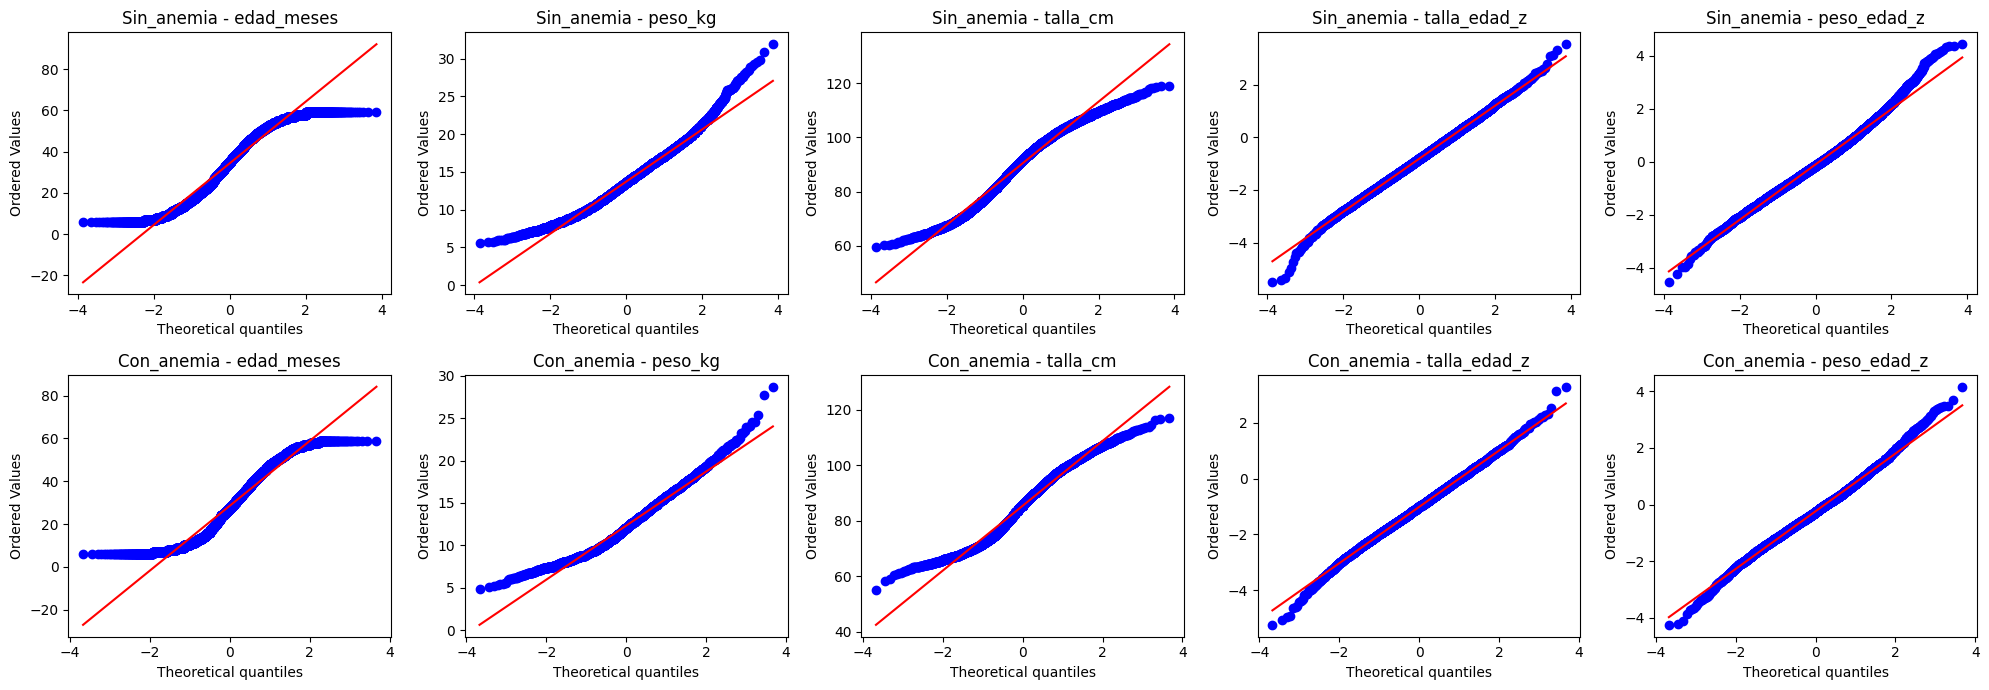

Grafico guardado: 3_qqplots.png


In [9]:
# =====================================================================
# SUPUESTO 1: NORMALIDAD UNIVARIANTE (Shapiro-Wilk por variable y grupo)
# =====================================================================
print("\n" + "=" * 70)
print("SUPUESTO: NORMALIDAD UNIVARIANTE (Test de Shapiro-Wilk)")
print("=" * 70)
print("Ho: la variable se distribuye normalmente dentro del grupo\n")

resultados_shapiro = []
for grupo in datos[Y_col].unique():
    for col in X_cols:
        muestra = datos[datos[Y_col] == grupo][col]
        muestra_test = muestra.sample(min(500, len(muestra)), random_state=1)
        stat, p = stats.shapiro(muestra_test)
        resultados_shapiro.append({'grupo': grupo, 'variable': col,
                                    'estadistico_W': round(stat, 4),
                                    'p_value': round(p, 5)})

df_shapiro = pd.DataFrame(resultados_shapiro)
print(df_shapiro.to_string(index=False))
print("\nNota: con N grande, Shapiro-Wilk tiende a rechazar Ho por desviaciones")
print("minimas de la normalidad. Se complementa con histogramas/QQ-plot y se")
print("recuerda que LDA es razonablemente robusto a apartamientos moderados.")

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for i, grupo in enumerate(['Sin_anemia', 'Con_anemia']):
    for j, col in enumerate(X_cols):
        muestra = datos[datos[Y_col] == grupo][col]
        stats.probplot(muestra, dist="norm", plot=axes[i, j])
        axes[i, j].set_title(f"{grupo} - {col}")
plt.tight_layout()
plt.savefig('3_qqplots.png', dpi=120)
plt.show()
print("Grafico guardado: 3_qqplots.png")

## Supuesto 2: Normalidad multivariante (Test de Mardia)

Contrastamos la normalidad conjunta de las 5 variables (test de Mardia: asimetria y curtosis multivariante).

In [10]:
# =====================================================================
# SUPUESTO 2: NORMALIDAD MULTIVARIANTE (Test de Mardia)
# =====================================================================
print("\n" + "=" * 70)
print("SUPUESTO: NORMALIDAD MULTIVARIANTE (Test de Mardia - Skewness/Kurtosis)")
print("=" * 70)

def mardia_test(X):
    """Test de Mardia de asimetria y curtosis multivariante."""
    n, p = X.shape
    Xc = X - X.mean(axis=0)
    S = np.cov(Xc, rowvar=False, bias=True)
    S_inv = np.linalg.inv(S)

    b1p = 0
    for i in range(n):
        for j in range(n):
            b1p += (Xc[i] @ S_inv @ Xc[j])**3
    b1p = b1p / n**2
    gl = p*(p+1)*(p+2)/6
    stat_skew = n*b1p/6
    p_skew = 1 - chi2.cdf(stat_skew, gl)

    b2p = np.mean([ (Xc[i] @ S_inv @ Xc[i])**2 for i in range(n)])
    stat_kurt = (b2p - p*(p+2)) / np.sqrt(8*p*(p+2)/n)
    p_kurt = 2*(1 - stats.norm.cdf(abs(stat_kurt)))

    return {'skewness_stat': stat_skew, 'skewness_p': p_skew,
            'kurtosis_stat': stat_kurt, 'kurtosis_p': p_kurt}

muestra_mardia = datos.sample(min(2000, len(datos)), random_state=1)
res_mardia = mardia_test(muestra_mardia[X_cols].values)
print(f"Mardia Skewness : estadistico = {res_mardia['skewness_stat']:.3f}, p-value = {res_mardia['skewness_p']:.5f}")
print(f"Mardia Kurtosis : estadistico = {res_mardia['kurtosis_stat']:.3f}, p-value = {res_mardia['kurtosis_p']:.5f}")
print("(Calculado sobre una submuestra de 2000 obs. por costo computacional O(n^2))")


SUPUESTO: NORMALIDAD MULTIVARIANTE (Test de Mardia - Skewness/Kurtosis)
Mardia Skewness : estadistico = 6434.005, p-value = 0.00000
Mardia Kurtosis : estadistico = 67.907, p-value = 0.00000
(Calculado sobre una submuestra de 2000 obs. por costo computacional O(n^2))


## Supuesto 3: Homogeneidad de matrices de covarianza (Test M de Box)

Contrastamos si la matriz de covarianzas es igual en ambos grupos. Es el supuesto clave que justifica el uso de LDA (covarianza compartida entre grupos).

In [11]:
# =====================================================================
# SUPUESTO 3: HOMOGENEIDAD DE MATRICES DE COVARIANZA (M de Box)
# =====================================================================
print("\n" + "=" * 70)
print("SUPUESTO: HOMOGENEIDAD DE VARIANZAS-COVARIANZAS (Test M de Box)")
print("=" * 70)
print("Ho: las matrices de covarianza son iguales entre grupos")
print("(Es el supuesto clave que justifica el uso de LDA)\n")

def box_m_test(datos, X_cols, y_col):
    grupos = datos[y_col].unique()
    p = len(X_cols)
    n_total = len(datos)
    g = len(grupos)

    S_list, n_list = [], []
    S_pooled = np.zeros((p, p))
    for grp in grupos:
        Xg = datos[datos[y_col] == grp][X_cols].values
        ng = Xg.shape[0]
        Sg = np.cov(Xg, rowvar=False)
        S_list.append(Sg)
        n_list.append(ng)
        S_pooled += (ng - 1) * Sg
    S_pooled = S_pooled / (n_total - g)

    log_det_pooled = np.linalg.slogdet(S_pooled)[1]
    M = (n_total - g) * log_det_pooled
    for ng, Sg in zip(n_list, S_list):
        M -= (ng - 1) * np.linalg.slogdet(Sg)[1]

    c1 = sum(1/(ng-1) for ng in n_list) - 1/(n_total - g)
    c1 = c1 * (2*p**2 + 3*p - 1) / (6*(p+1)*(g-1))
    chi2_stat = M * (1 - c1)
    gl = 0.5 * p * (p+1) * (g-1)
    p_value = 1 - chi2.cdf(chi2_stat, gl)
    return chi2_stat, gl, p_value

chi2_stat, gl, p_value = box_m_test(datos, X_cols, Y_col)
print(f"Estadistico Chi-cuadrado (aprox.) = {chi2_stat:.3f}")
print(f"Grados de libertad = {gl:.0f}")
print(f"p-value = {p_value:.6f}")
if p_value < 0.001:
    print("\n-> Se RECHAZA Ho (p < 0.001, criterio conservador recomendado para Box's M).")
    print("   Las matrices de covarianza NO son homogeneas. El LDA sigue siendo valido como")
    print("   primera aproximacion, pero conviene tener en cuenta esta limitacion al interpretar resultados.")
else:
    print("\n-> NO se rechaza Ho. Las matrices de covarianza pueden considerarse homogeneas -> LDA es adecuado.")


SUPUESTO: HOMOGENEIDAD DE VARIANZAS-COVARIANZAS (Test M de Box)
Ho: las matrices de covarianza son iguales entre grupos
(Es el supuesto clave que justifica el uso de LDA)

Estadistico Chi-cuadrado (aprox.) = 2277.788
Grados de libertad = 15
p-value = 0.000000

-> Se RECHAZA Ho (p < 0.001, criterio conservador recomendado para Box's M).
   Las matrices de covarianza NO son homogeneas. El LDA sigue siendo valido como
   primera aproximacion, pero conviene tener en cuenta esta limitacion al interpretar resultados.


## Paso 3: Entrenar el modelo LDA

Ajustamos el modelo LDA (procedimiento de Fisher), mostrando medias por grupo, coeficientes y la funcion discriminante lineal.

In [12]:
# =====================================================================
# PASO 3: ENTRENAR EL MODELO LDA
# =====================================================================
print("\n" + "=" * 70)
print("PASO 3: ENTRENAMIENTO DEL MODELO LDA")
print("=" * 70)

lda = LinearDiscriminantAnalysis(solver='svd', store_covariance=True)
lda.fit(X_train, y_train)
print("\n--- MODELO LDA ---")
print("Clases:", lda.classes_)
print("Probabilidades previas (priors):", dict(zip(lda.classes_, lda.priors_.round(4))))
print("\nMedias por grupo:")
medias = pd.DataFrame(lda.means_, columns=X_cols, index=lda.classes_)
print(medias.round(3))

print("\nCoeficientes de la funcion discriminante lineal:")
coef_lda = pd.DataFrame(lda.coef_, columns=X_cols, index=['LD1'])
print(coef_lda.round(5))
print(f"Intercepto: {lda.intercept_[0]:.5f}")

print("\nFuncion discriminante (LDA):")
terms = " + ".join([f"({c:.5f})*{n}" for c, n in zip(lda.coef_[0], X_cols)])
print(f"D = {lda.intercept_[0]:.5f} + {terms}")


PASO 3: ENTRENAMIENTO DEL MODELO LDA

--- MODELO LDA ---
Clases: ['Con_anemia' 'Sin_anemia']
Probabilidades previas (priors): {np.str_('Con_anemia'): np.float64(0.3143), np.str_('Sin_anemia'): np.float64(0.6857)}

Medias por grupo:
            edad_meses  peso_kg  talla_cm  talla_edad_z  peso_edad_z
Con_anemia      28.614   12.338    85.471        -1.015       -0.245
Sin_anemia      34.361   13.694    90.466        -0.822       -0.107

Coeficientes de la funcion discriminante lineal:
     edad_meses  peso_kg  talla_cm  talla_edad_z  peso_edad_z
LD1    -0.02854 -0.07912   0.09545      -0.13469      0.13848
Intercepto: -5.78784

Funcion discriminante (LDA):
D = -5.78784 + (-0.02854)*edad_meses + (-0.07912)*peso_kg + (0.09545)*talla_cm + (-0.13469)*talla_edad_z + (0.13848)*peso_edad_z


## Correlacion canonica y autovalor (poder discriminante)

Calculamos el autovalor y la correlacion canonica de la funcion discriminante (mide cuanta separacion entre grupos logra).

In [13]:
# =====================================================================
# CORRELACION CANONICA Y AUTOVALOR (lambda)
# =====================================================================
print("\n" + "=" * 70)
print("PODER DISCRIMINANTE: AUTOVALOR Y CORRELACION CANONICA")
print("=" * 70)

def autovalor_lda(X, y, X_cols):
    grupos = np.unique(y)
    p = len(X_cols)
    n = len(X)
    medias_totales = X.mean(axis=0)

    W = np.zeros((p, p))
    B = np.zeros((p, p))
    for g in grupos:
        Xg = X[y == g]
        ng = Xg.shape[0]
        mg = Xg.mean(axis=0)
        W += (Xg - mg).T @ (Xg - mg)
        diff = (mg - medias_totales).reshape(-1, 1)
        B += ng * (diff @ diff.T)

    eigvals, eigvecs = np.linalg.eig(np.linalg.inv(W) @ B)
    eigvals = np.real(eigvals)
    eigvals = np.sort(eigvals)[::-1]
    return eigvals

eigvals = autovalor_lda(X_train, y_train, X_cols)
lambda1 = eigvals[0]
corr_canonica = np.sqrt(lambda1 / (1 + lambda1))
print(f"Autovalor (lambda1) = {lambda1:.4f}")
print(f"Correlacion canonica = {corr_canonica:.4f}")
print("(Valor cercano a 1 indica mayor poder discriminante de la funcion)")


PODER DISCRIMINANTE: AUTOVALOR Y CORRELACION CANONICA
Autovalor (lambda1) = 0.0428
Correlacion canonica = 0.2026
(Valor cercano a 1 indica mayor poder discriminante de la funcion)


## Lambda de Wilks (significancia de la funcion discriminante)

Evaluamos si la funcion discriminante es estadisticamente significativa (Ho: las medias de la funcion son iguales en todos los grupos).

In [14]:
# =====================================================================
# LAMBDA DE WILKS (significancia de la funcion discriminante)
# =====================================================================
print("\n" + "=" * 70)
print("LAMBDA DE WILKS (significancia global de la funcion discriminante)")
print("=" * 70)
print("Ho: las medias de la funcion discriminante son iguales en todos los grupos\n")

wilks_lambda = 1 / (1 + lambda1)
n_train = len(X_train)
p = len(X_cols)
g = len(np.unique(y_train))

gl_wilks = p * (g - 1)
chi2_wilks = -(n_train - 1 - (p + g)/2) * np.log(wilks_lambda)
p_wilks = 1 - chi2.cdf(chi2_wilks, gl_wilks)

print(f"Lambda de Wilks = {wilks_lambda:.5f}")
print(f"Chi-cuadrado aproximado = {chi2_wilks:.3f}, gl = {gl_wilks}")
print(f"p-value = {p_wilks:.6f}")
if p_wilks < 0.05:
    print("-> Se rechaza Ho: la funcion discriminante SI es estadisticamente significativa.")
else:
    print("-> No se rechaza Ho: la funcion discriminante no resulta significativa.")


LAMBDA DE WILKS (significancia global de la funcion discriminante)
Ho: las medias de la funcion discriminante son iguales en todos los grupos

Lambda de Wilks = 0.95894
Chi-cuadrado aproximado = 537.065, gl = 5
p-value = 0.000000
-> Se rechaza Ho: la funcion discriminante SI es estadisticamente significativa.


## Paso 4: Evaluar el modelo (matriz de confusion, accuracy, validacion cruzada)

Calculamos accuracy, matriz de confusion, reporte de clasificacion y validacion cruzada 10-fold sobre el conjunto de prueba.


PASO 4: EVALUACION DEL MODELO - PREDICCIONES EN TEST
Accuracy (test) = 68.68%
Error de clasificacion (test) = 31.32%

Matriz de confusion:
                 Pred_Con_anemia  Pred_Sin_anemia
Real_Con_anemia              146             1580
Real_Sin_anemia              140             3626

Reporte de clasificacion:
              precision    recall  f1-score   support

  Con_anemia       0.51      0.08      0.15      1726
  Sin_anemia       0.70      0.96      0.81      3766

    accuracy                           0.69      5492
   macro avg       0.60      0.52      0.48      5492
weighted avg       0.64      0.69      0.60      5492

Validacion cruzada 10-fold: accuracy promedio = 68.58% (+/- 0.23%)


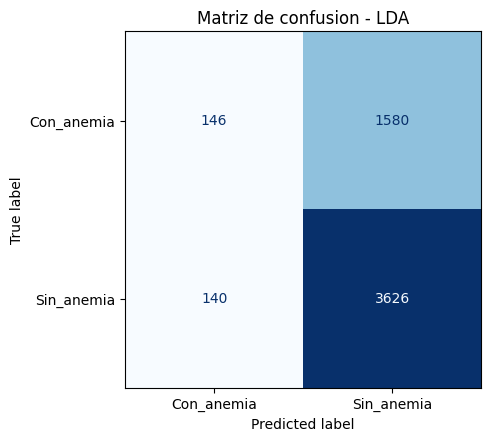


Grafico guardado: 4_matriz_confusion.png


In [15]:
# =====================================================================
# PASO 4: EVALUAR EL MODELO (predicciones, matriz de confusion)
# =====================================================================
print("\n" + "=" * 70)
print("PASO 4: EVALUACION DEL MODELO - PREDICCIONES EN TEST")
print("=" * 70)

pred = lda.predict(X_test)
proba = lda.predict_proba(X_test)

acc = accuracy_score(y_test, pred)
print(f"Accuracy (test) = {acc*100:.2f}%")
print(f"Error de clasificacion (test) = {(1-acc)*100:.2f}%")

cm = confusion_matrix(y_test, pred, labels=lda.classes_)
print("\nMatriz de confusion:")
print(pd.DataFrame(cm, index=[f"Real_{c}" for c in lda.classes_],
                    columns=[f"Pred_{c}" for c in lda.classes_]))

print("\nReporte de clasificacion:")
print(classification_report(y_test, pred, target_names=lda.classes_))

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
cv_scores = cross_val_score(lda, X, y, cv=cv, scoring='accuracy')
print(f"Validacion cruzada 10-fold: accuracy promedio = {cv_scores.mean()*100:.2f}% "
      f"(+/- {cv_scores.std()*100:.2f}%)")

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lda.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Matriz de confusion - LDA")
plt.tight_layout()
plt.savefig('4_matriz_confusion.png', dpi=120)
plt.show()
print("\nGrafico guardado: 4_matriz_confusion.png")

## Paso 5: Curva ROC y AUC

Graficamos la curva ROC y calculamos el AUC del modelo LDA.


PASO 5: CURVA ROC Y AREA BAJO LA CURVA (AUC)


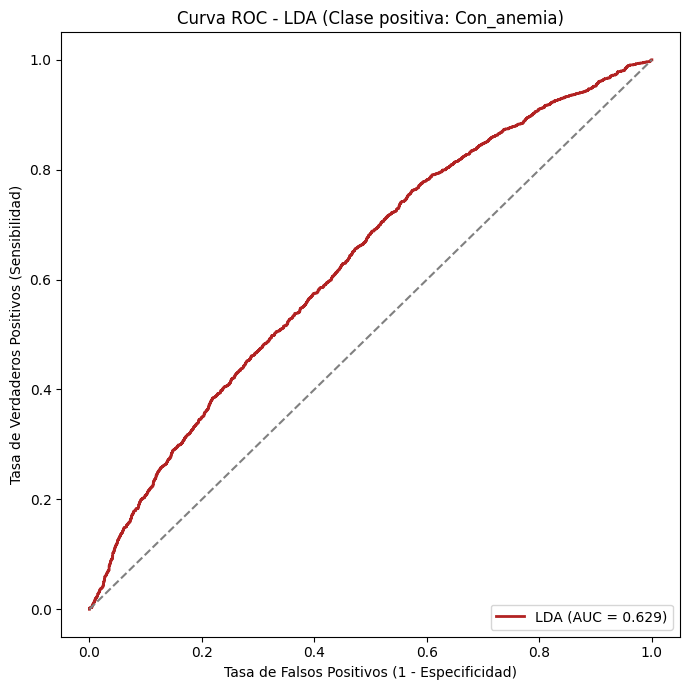

AUC (LDA) = 0.6293
Grafico guardado: 5_curva_roc.png


In [16]:
# =====================================================================
# PASO 5: CURVA ROC Y AUC
# =====================================================================
print("\n" + "=" * 70)
print("PASO 5: CURVA ROC Y AREA BAJO LA CURVA (AUC)")
print("=" * 70)

clase_positiva = 'Con_anemia'
idx_pos = list(lda.classes_).index(clase_positiva)
proba_test = lda.predict_proba(X_test)[:, idx_pos]
fpr, tpr, _ = roc_curve(y_test, proba_test, pos_label=clase_positiva)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, label=f"LDA (AUC = {roc_auc:.3f})", color="firebrick", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
ax.set_title(f"Curva ROC - LDA (Clase positiva: {clase_positiva})")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig('5_curva_roc.png', dpi=120)
plt.show()
print(f"AUC (LDA) = {roc_auc:.4f}")
print("Grafico guardado: 5_curva_roc.png")

## Paso 6: Prediccion para una nueva observacion

Clasificamos un nuevo caso hipotetico (un nino con ciertas medidas) usando el modelo LDA entrenado.

In [17]:
# =====================================================================
# PASO 6: PREDICCION PARA NUEVAS OBSERVACIONES
# =====================================================================
print("\n" + "=" * 70)
print("PASO 6: PREDICCION PARA UN NUEVO CASO")
print("=" * 70)

nuevo_caso = pd.DataFrame({
    'edad_meses': [24],
    'peso_kg': [11.5],
    'talla_cm': [84],
    'talla_edad_z': [-1.2],
    'peso_edad_z': [-0.8]
})
print("Nuevo caso a clasificar:")
print(nuevo_caso)

pred_nuevo = lda.predict(nuevo_caso[X_cols].values)[0]
proba_nuevo = lda.predict_proba(nuevo_caso[X_cols].values)[0]
print(f"\nLDA -> Clase predicha: {pred_nuevo}")
print(f"LDA -> Probabilidades: {dict(zip(lda.classes_, proba_nuevo.round(4)))}")


PASO 6: PREDICCION PARA UN NUEVO CASO
Nuevo caso a clasificar:
   edad_meses  peso_kg  talla_cm  talla_edad_z  peso_edad_z
0          24     11.5        84          -1.2         -0.8

LDA -> Clase predicha: Sin_anemia
LDA -> Probabilidades: {np.str_('Con_anemia'): np.float64(0.3349), np.str_('Sin_anemia'): np.float64(0.6651)}
